In [24]:
from votekit.pref_profile import PreferenceProfile, RankProfile
from votekit.cvr_loaders import load_scottish, load_ranking_csv, load_numpy

D1_profile = load_numpy("/home/nardo/research/data/election_data/votekit/portland/portland_d1_2024.csv")[0]
D4_profile = load_numpy("/home/nardo/research/data/election_data/votekit/portland/portland_d4_2024.csv")[0]

#albany_pf = RankProfile.from_csv("/home/nardo/research/data/election_data/albany/albany_profile.csv")
#minneapolis = load_ranking_csv("/home/nardo/research/data/misc_elections/mn_2013_cast_vote_record.csv",rank_cols= [0,1,2])

#perth_kinross = load_scottish("/home/nardo/research/data/election_data/scot-elex/6_cands/perth_kinross_2012_ward9.csv")[0]

#some_scottish_elec = load_scottish("/home/nardo/research/data/scot-elex/12_cands/highland_2017_ward10.csv")

#victoria_profile = load_numpy("/home/nardo/research/data/election_data/australia/votekit_csv/2025/vic_2025_votekit.csv")[0]
#qld_profile = load_scottish("/home/nardo/research/data/australia/votekit_csv/2025/qld_2025_votekit.csv")[0]

#cambridge_profile = RankProfile.from_csv("/home/nardo/research/data/election_data/cambridge/cambridge_2021/city_council/ca_ma_city_council_2021_votekit_deduplicated.csv")

#cambridge_2001 =RankProfile.from_csv("/home/nardo/research/data/election_data/cambridge/cambridge_2001/city_council/ca_ma_city_council_2001_votekit_deduplicated.csv")

#minneapolis_2_seat_2021 = RankProfile.from_csv("/home/nardo/research/data/election_data/minneapolis/bot_minn_2021_votekit_deduplicated.csv")
profile = D1_profile

#print(some_scottish_elec[1:])

In [25]:
from votekit.elections import FastSTV
from votekit.pref_profile.numpy_profile import remove_and_condense_numpy_profile, rank_profile_to_numpy_profile, remove_and_reweigh_and_condense
from votekit.utils import mentions_from_numpy_arrays

elec = FastSTV(D4_profile, 3, simultaneous=False)
elec.get_score_df()

,Round 0,Round 1,Round 2,Round 3,Round 4,Round 5,Round 6,Round 7,Round 8,Round 9,...,Round 21,Round 22,Round 23,Round 24,Round 25,Round 26,Round 27,Round 28,Round 29,Round 30
Olivia Clark,19144.0,Elected,Elected,Elected,Elected,Elected,Elected,Elected,Elected,Elected,...,Elected,Elected,Elected,Elected,Elected,Elected,Elected,Elected,Elected,Elected
Mitch Green,10392.0,10392.11,10393.11,10409.11,10412.11,10418.11,10421.11,10428.11,10446.11,10465.11,...,11644.12,11756.13,12024.13,12821.15,14417.17,16705.2,20159.29,Elected,Elected,Elected
Eric Zimmerman,8009.0,8009.97,8009.97,8013.97,8023.97,8044.97,8069.97,8075.97,8088.97,8094.97,...,8976.99,9407.0,10159.02,11056.04,11512.06,12349.08,13661.16,13783.79,20245.76,Elected
Eli Arnold,8128.0,8128.2,8130.2,8140.2,8142.2,8156.2,8190.2,8205.2,8214.2,8231.2,...,9228.22,9644.22,9933.23,11188.25,11488.26,12095.27,12821.31,12914.77,0.0,0.0
Sarah Silkie,4419.0,4419.19,4421.19,4422.19,4430.19,4434.19,4437.19,4468.19,4490.19,4500.19,...,5601.21,5781.21,5991.22,6368.22,7702.27,9322.29,0.0,0.0,0.0,0.0
Chad Lykins,4761.0,4761.07,4761.07,4764.07,4775.07,4776.07,4778.07,4787.07,4802.07,4817.07,...,5476.08,5602.08,5949.08,6244.09,7042.1,0.0,0.0,0.0,0.0,0.0
Lisa Freeman,3754.0,3754.11,3754.11,3758.11,3761.11,3766.11,3772.11,3793.11,3820.11,3849.11,...,5080.12,5182.13,5377.13,5680.13,0.0,0.0,0.0,0.0,0.0,0.0
Bob Weinstein,3898.0,3898.07,3899.07,3900.07,3907.07,3908.07,3910.07,3918.07,3930.07,3937.07,...,4618.08,4856.08,4979.09,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Tony Morse,2006.0,2006.05,2006.05,2010.05,2016.05,2018.05,2023.05,2024.05,2033.05,2044.05,...,2543.06,2663.06,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ben Hufford,1696.0,1696.04,1696.04,1696.04,1700.04,1702.04,1708.04,1709.04,1711.04,1714.04,...,2107.04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
D4_strong = elec.get_ranking()[:6]
print(D4_strong)
not_strong = [c for c in D4_profile.candidates if c not in D4_strong]
D4_numpy = rank_profile_to_numpy_profile(D4_profile)
D4_just_strong = remove_and_condense_numpy_profile(D4_numpy, not_strong)
strong_elec = FastSTV(D4_just_strong, 3, simultaneous=False)
olivia_tranfer_value = (23604-18098)/23604
generous_profile = remove_and_reweigh_and_condense(D4_numpy, ["Olivia Clark"], [olivia_tranfer_value])

generous_mentions = mentions_from_numpy_arrays(generous_profile, freeze_fpv=D4_strong[1:])
generous_mentions

In [3]:
D4_weak = [c for c, score in generous_mentions.items() if score <4419]
D4_weak_idx = [D4_profile.candidates.index(c) for c in D4_weak]
D4_strong_idx = [D4_profile.candidates.index(c) for c in D4_strong]

In [16]:
from votekit.utils import mentions, mentions_from_numpy_arrays
from votekit.elections import FastSTV, MeekSTV
from votekit.pref_profile import rank_profile_to_numpy_profile, NumpyRankProfile
from votekit.pref_profile.numpy_profile import remove_and_condense_numpy_profile, numpy_profile_fpv
import math

def find_weak_from_strong(profile, strong_cands, m, LAM):
    if type(profile) == RankProfile:
        profile = rank_profile_to_numpy_profile(profile)
    assert type(profile) == NumpyRankProfile
    non_strong_cands = [c for c in profile.candidates if c not in strong_cands]
    strong_cands_pf = remove_and_condense_numpy_profile(profile, non_strong_cands)
    strong_cands_fpv = numpy_profile_fpv(strong_cands_pf)
    quota = math.floor(profile.total_ballot_wt/(m+1)) + 1
    for c, score in strong_cands_fpv.items():
        if score + LAM >= quota:
                raise ValueError(
               f"Strong candidate {c} has FPV {score} which is more than quota {quota} minus LAM {LAM}")
    initial_fpv = numpy_profile_fpv(profile)
    smallest_strong_fpv = min(score for c, score in initial_fpv.items() if c in strong_cands)
    frozen_mentions = mentions_from_numpy_arrays(profile, freeze_fpv=strong_cands)
    weak_cands = [c for c, score in frozen_mentions.items() if score <= smallest_strong_fpv]
    return weak_cands


    # check if the strong cands would not have quota on their own
elec = FastSTV(profile, 2,simultaneous=False)
elec.get_score_df(starting_round=0)

,Round 0,Round 1,Round 2,Round 3,Round 4,Round 5,Round 6
Steve Brandt,42658.0,Elected,Elected,Elected,Elected,Elected,Elected
"Samantha ""Sam"" Pree-Stinson",25588.0,27289.86,27302.12,27328.63,29678.59,42879.25,Elected
Pine Salica,20776.0,22658.6,22671.1,22691.86,24273.53,0.0,0.0
Kevin Nikiforakis,5804.0,7085.57,7096.57,7116.58,0.0,0.0,0.0
writein,754.0,809.28,810.28,0.0,0.0,0.0,0.0
overvote,89.0,92.53,0.0,0.0,0.0,0.0,0.0
Quota,31890.0,31890.0,31890.0,31890.0,31890.0,31890.0,31890.0


In [6]:
weak

['Laura Streib',
 'Michael (Mike) Marshall',
 'Nabil Zaghloul',
 'Chris Olson',
 'Sam Sachs',
 'Antonio Jamal PettyJohnBlue',
 'James Armstrong',
 'Reuben Berlin',
 'Jennifer Park',
 'Bob Simril',
 'Debbie Kitchin',
 'Will Mespelt',
 'Liz Taylor']

In [8]:
from votekit.elections import MeekSTV

meek_D4 = MeekSTV(D4_profile, 3)
meek_D4.get_score_df()

,Round 0,Round 1,Round 2,Round 3,Round 4,Round 5,Round 6,Round 7,Round 8,Round 9,...,Round 19,Round 20,Round 21,Round 22,Round 23,Round 24,Round 25,Round 26,Round 27,Round 28
Olivia Clark,19144.0,19141.48,19140.45,19136.36,19133.22,19129.66,19121.04,19111.29,19105.35,19095.56,...,18803.09,18758.08,18636.77,18552.36,18441.62,18202.17,17955.48,17570.05,16730.09,15827.66
Mitch Green,10392.0,10392.14,10393.31,10408.87,10410.66,10417.03,10419.79,10428.29,10447.40,10464.21,...,11025.18,11459.88,11687.16,11808.43,12096.81,12921.34,14520.77,16834.02,20371.73,15827.66
Eric Zimmerman,8009.0,8010.23,8011.70,8019.60,8034.47,8058.66,8089.28,8108.26,8130.91,8151.34,...,9342.69,9466.92,9695.36,10219.70,10976.33,12159.00,12958.15,14219.09,16477.23,17686.89
Eli Arnold,8128.0,8128.25,8128.55,8137.56,8139.97,8154.63,8189.99,8200.71,8210.71,8230.90,...,8967.94,9023.14,9312.65,9714.16,10053.59,11318.83,11675.44,12376.69,13341.32,13968.43
Sarah Silkie,4419.0,4419.24,4421.53,4423.49,4432.83,4436.45,4440.75,4473.31,4495.23,4507.28,...,5182.25,5473.62,5613.42,5808.11,6046.26,6435.85,7650.94,9280.34,0.00,0.00
Chad Lykins,4761.0,4761.09,4761.19,4764.54,4774.03,4774.26,4776.74,4786.67,4802.36,4818.46,...,5258.18,5407.88,5502.44,5624.17,5973.54,6273.42,7061.15,0.00,0.00,0.00
Lisa Freeman,3754.0,3754.13,3754.29,3756.82,3760.57,3764.91,3770.65,3791.09,3817.16,3842.92,...,4483.84,4736.40,4846.27,4962.26,5171.56,5498.07,0.00,0.00,0.00,0.00
Bob Weinstein,3898.0,3898.09,3899.19,3900.53,3908.02,3909.24,3911.70,3919.62,3930.31,3938.40,...,4399.23,4482.05,4632.16,4862.00,5006.78,0.00,0.00,0.00,0.00,0.00
Tony Morse,2006.0,2006.06,2006.13,2010.37,2015.71,2017.87,2022.19,2023.83,2032.34,2044.11,...,2330.29,2421.13,2542.70,2658.24,0.00,0.00,0.00,0.00,0.00,0.00
Ben Hufford,1696.0,1696.05,1696.10,1696.29,1700.55,1702.67,1707.93,1709.43,1711.80,1715.39,...,1988.88,2008.00,2078.13,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [5]:
D2_numpy = rank_profile_to_numpy_profile(D2_profile)

strong = ['Sameer Kanal','Dan Ryan','Elana Pirtle-Guiney','Tiffani Penson','Nat West','Michelle DePass']
weak = find_weak_from_strong(D2_profile, strong_cands=strong, m=3, LAM=800)

In [ ]:
D3_strong = ["Steve Novick", "Tiffany Koyama Lane", "Angelita Morillo"]

In [16]:
from votekit.utils import mentions_from_numpy_arrays
from votekit.pref_profile import convert_row_to_rank_ballot

D3_numpy = rank_profile_to_numpy_profile(D3_profile)
D3_strong_idx = [D3_numpy.candidates.index(c) for c in D3_strong]
mentions = mentions_from_numpy_arrays(D3_numpy, freeze_fpv=D3_strong_idx)
mentions

{'Dan Gilk': 2334.0,
 'Matthew (Matt) Anderson': 3080.0,
 'Chris Flanary': 4954.0,
 'Melodie Beirwagen': 4119.0,
 'Jaclyn Smith-Moore': 807.0,
 'Cristal Azul Otero': 6088.0,
 'Kenneth (Kent) R Landgraver III': 1362.0,
 'Heart Free Pham': 2177.0,
 'John Sweeney': 1124.0,
 'Luke Zak': 3023.0,
 'Harrison Kass': 7124.0,
 'Brian Conley': 2772.0,
 'Terry Parker': 2372.0,
 'Clifford Higgins': 685.0,
 'Christopher Brummer': 1203.0,
 'Jonathan (Jon) Walker': 5175.0,
 'Kelly Janes (KJ)': 1569.0,
 'Ahlam K Osman': 3199.0,
 'Sandeep Bali': 5348.0,
 "David O'Connor": 727.0,
 'Rex Burkholder': 10390.0,
 'Patrick Hilton': 1095.0,
 'Jesse Cornett': 11553.0,
 'Kezia Wanner': 11872.0,
 'Daniel DeMelo': 7323.0,
 'Theo Hathaway Saner': 1432.0,
 'Philippe Knab': 6082.0}

In [25]:
weak_as_idx = [D2_numpy.candidate_to_index[c] for c in weak]
strong_as_idx = [D2_numpy.candidate_to_index[c] for c in strong]

In [ ]:
from src.wigm_graphs.graph_wigm import WIGMGraphConstructor
from src.meek_graphs.graph_meek import MeekGraphConstructor

constructor = WIGMGraphConstructor(D4_profile, m=3, LAM=800, memory_lite=True)

constructor.build()
#constructor.seeded_build(
#    weak_candidates=D4_weak_idx,
#    strong_candidates=D4_strong_idx,
#)

constructor.coherence_check()

#constructor.reverse_build([4,5,14])

#constructor1 = WIGMGraphConstructor(profile, m=3, LAM=100, memory_lite=True)
#constructor1.build()
#constructor1.expand_margin(300)
#constructor1.add_natural_edges()


In [10]:
constructor.find_minimal_upset_path()

Minimal upset path found.
  recorded winner set: ['Sameer Kanal', 'Dan Ryan', 'Elana Pirtle-Guiney']
  upset winner set:    ['Sameer Kanal', 'Tiffani Penson', 'Elana Pirtle-Guiney']
  source vertex:       P27
  terminal vertex:     W28
  tightest_margin:     3015.394839413557

Nonzero-margin steps:
round 1: + 20 instead of x 13. M = 2920.0
  hopefuls = [0, 6, 13, 15, 17, 20, 21]
  elected = []
round 2: x 6 instead of x 13. M = 27.882414152048568
  hopefuls = [0, 6, 13, 15, 17, 21]
  elected = [(20, np.float64(-0.17873538593376997))]
round 6: x 17 instead of x 15. M = 3015.394839413557
  hopefuls = [15, 17]
  elected = [(0, np.float64(0.05003311399739829)), (20, np.float64(-0.17873538593376997))]


[EdgeRef(layer=15, local_id=17),
 EdgeRef(layer=16, local_id=7),
 EdgeRef(layer=17, local_id=21),
 EdgeRef(layer=18, local_id=37),
 EdgeRef(layer=19, local_id=50),
 EdgeRef(layer=20, local_id=60),
 EdgeRef(layer=21, local_id=28)]

In [16]:
constructor.lookup_vertex("q0")

Vertex Q0
  ref: VertexRef(layer=16, local_id=0)
  status: TERMINAL
  degree: 3
  color: 3
  path_multiplicity: 0
  tightest_margin: None
  elected candidates:
    4
    5
    14
  hopefuls:


ElectionState(ref=VertexRef(layer=16, local_id=0), key=MeekStateKey(elected_candidates=(4, 5, 14), hopefuls=frozenset()), degree=3, tallies=None, keep_factors=None, quota=None, status=<ElectionStatus.TERMINAL: 2>, color=3, path_multiplicity=0, tightest_margin=None, next_margin=None)

In [12]:
constructor.lookup_edges_from("B0")

Outgoing edges from B0: 1
  EdgeRef(layer=1, local_id=0): B0 -> C0; ELIMINATE 9: Terrence Hayes; status=NOT_FACTUAL; margin=4425.0


[ElectionEdge(ref=EdgeRef(layer=1, local_id=0), src=VertexRef(layer=1, local_id=0), dst=VertexRef(layer=2, local_id=0), action=<EdgeAction.ELIMINATE: 1>, candidate=9, status=<EdgeStatus.NOT_FACTUAL: -1>, margin=4425.0, transfer_value=None, wt_vec=None)]

In [4]:
for layer in constructor.edge_layers:
    for edge in layer:
        if edge.candidate == 0:
            print(edge)

ElectionEdge(ref=EdgeRef(layer=13, local_id=13), src=VertexRef(layer=13, local_id=13), dst=VertexRef(layer=14, local_id=14), action=<EdgeAction.FORCE_ELECT: 2>, candidate=0, status=<EdgeStatus.DEFAULT: 0>, margin=0.0, transfer_value=None, wt_vec=None)
ElectionEdge(ref=EdgeRef(layer=14, local_id=13), src=VertexRef(layer=14, local_id=13), dst=VertexRef(layer=15, local_id=2), action=<EdgeAction.FORCE_ELECT: 2>, candidate=0, status=<EdgeStatus.DEFAULT: 0>, margin=0.0, transfer_value=None, wt_vec=None)
ElectionEdge(ref=EdgeRef(layer=14, local_id=28), src=VertexRef(layer=14, local_id=28), dst=VertexRef(layer=15, local_id=1), action=<EdgeAction.FORCE_ELECT: 2>, candidate=0, status=<EdgeStatus.DEFAULT: 0>, margin=0.0, transfer_value=None, wt_vec=None)
ElectionEdge(ref=EdgeRef(layer=15, local_id=0), src=VertexRef(layer=15, local_id=0), dst=VertexRef(layer=16, local_id=0), action=<EdgeAction.FORCE_ELECT: 2>, candidate=0, status=<EdgeStatus.DEFAULT: 0>, margin=0.0, transfer_value=None, wt_vec=Non

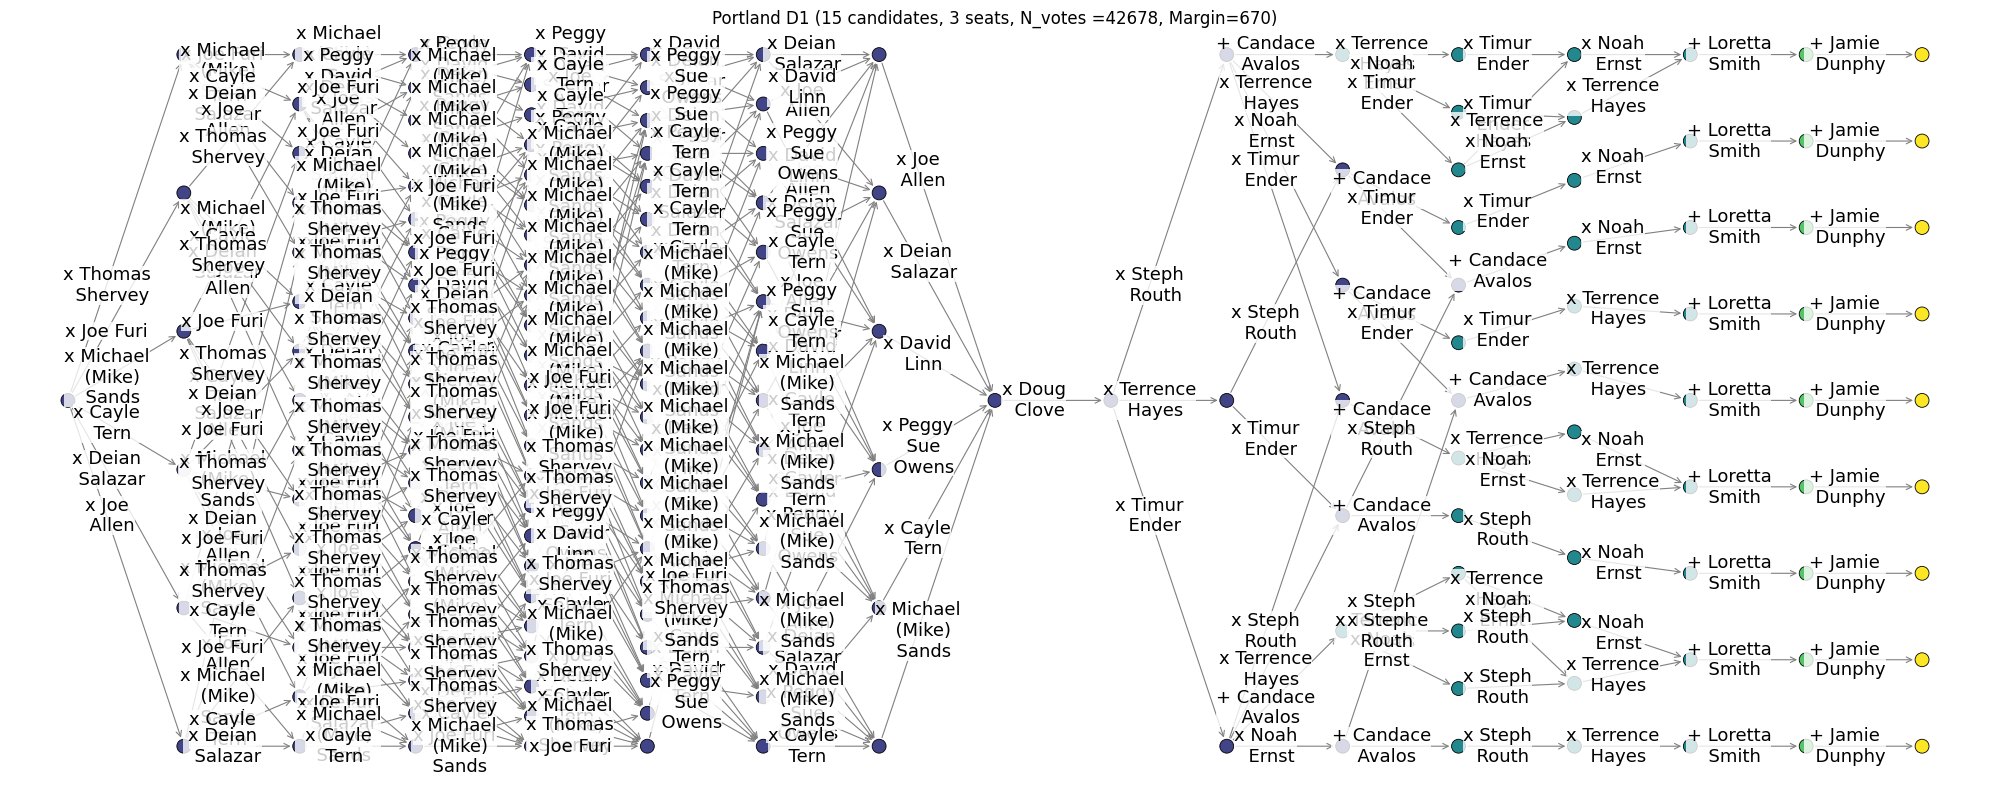

In [15]:
from src.plotting import plot_wigm_graph

plot_wigm_graph(
    constructor,
    figsize=(20, 8),
    node_size=100,
    font_size=14,
    label_edges= "literal",
    label_vertices=False,
    #lam_restriction=670,
    plot_horizontal=True,
    title="Portland D1 (15 candidates, 3 seats, N_votes =42678, Margin=670)"
)

In [23]:
sum([len(layer) for layer in constructor.layers[8:]])

64

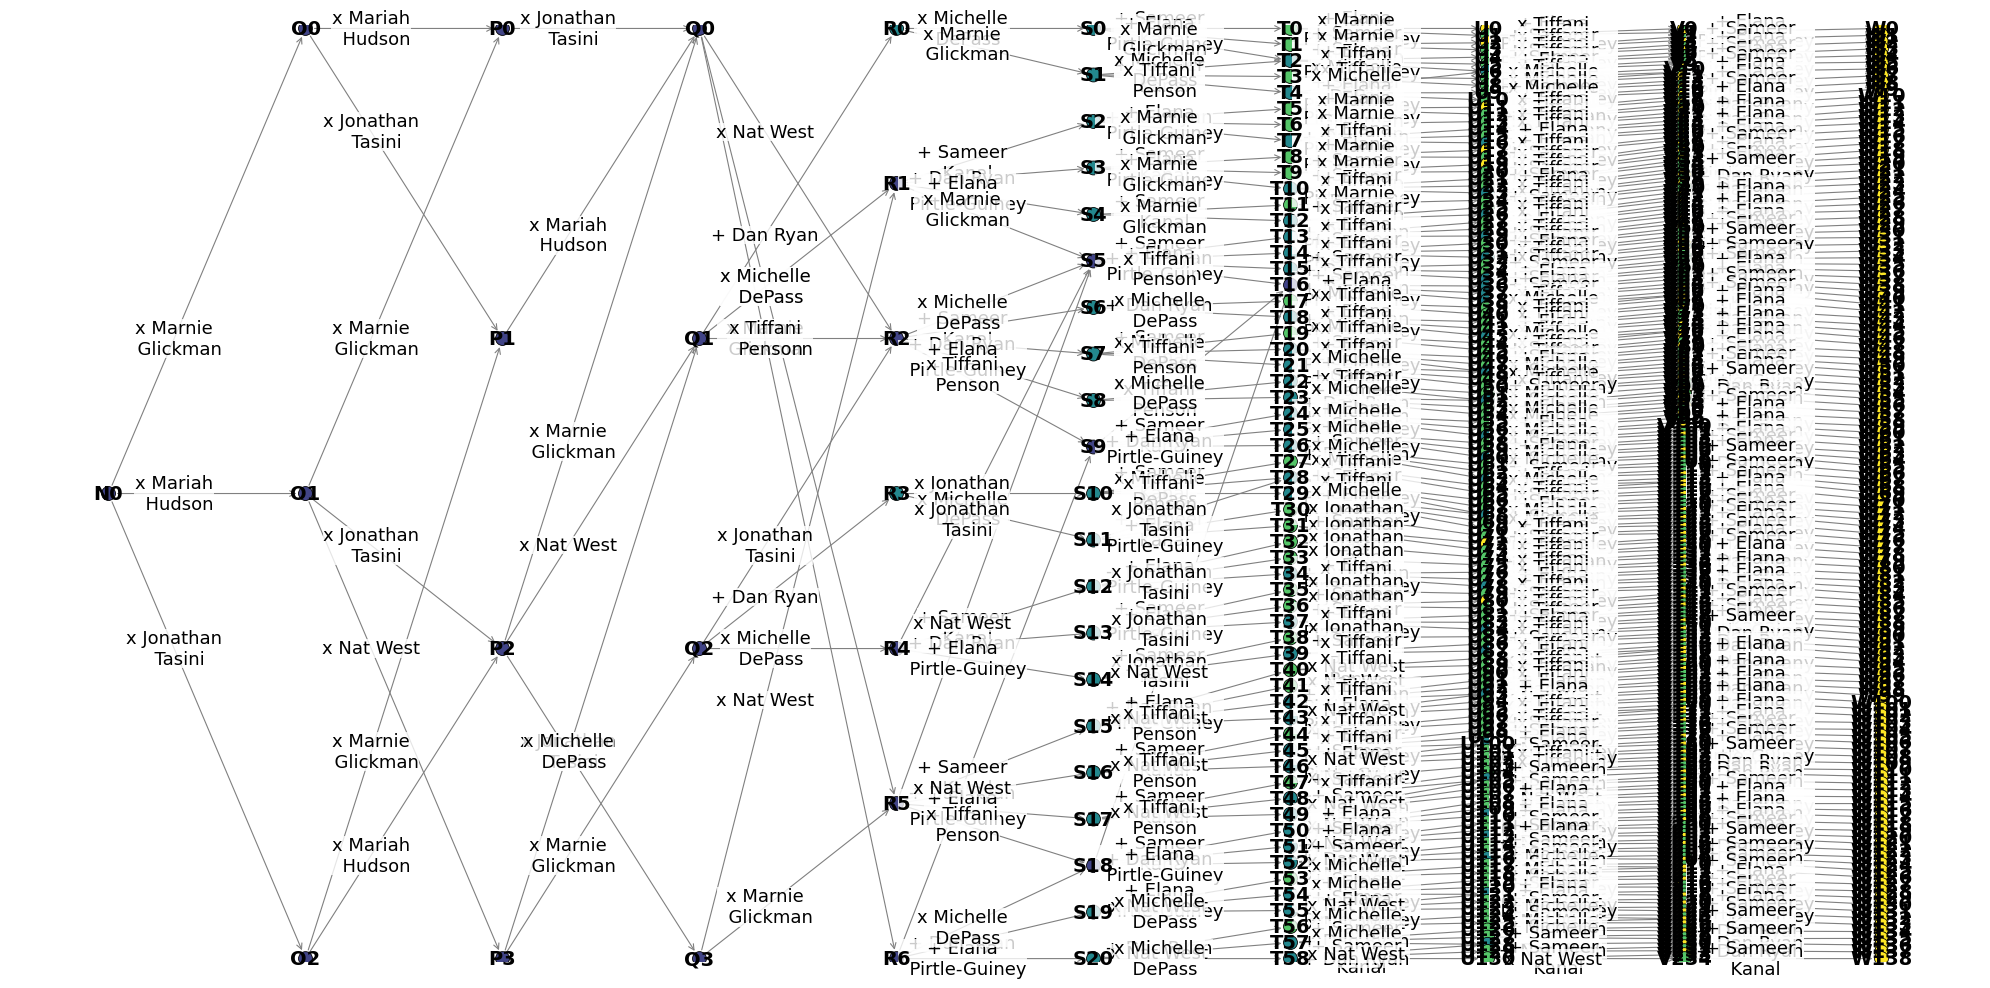

In [27]:
from src.plotting import plot_wigm_graph

plot_wigm_graph(
    constructor,
    figsize=(20, 10),
    node_size=100,
    font_size=14,
    #label_edges=None,
    label_vertices=True,
    #lam_restriction=670,
    plot_horizontal=True,
    title="",
    #title="Portland D2 (15 candidates, 3 seats, N_votes =42678, Margin=2000)"
)

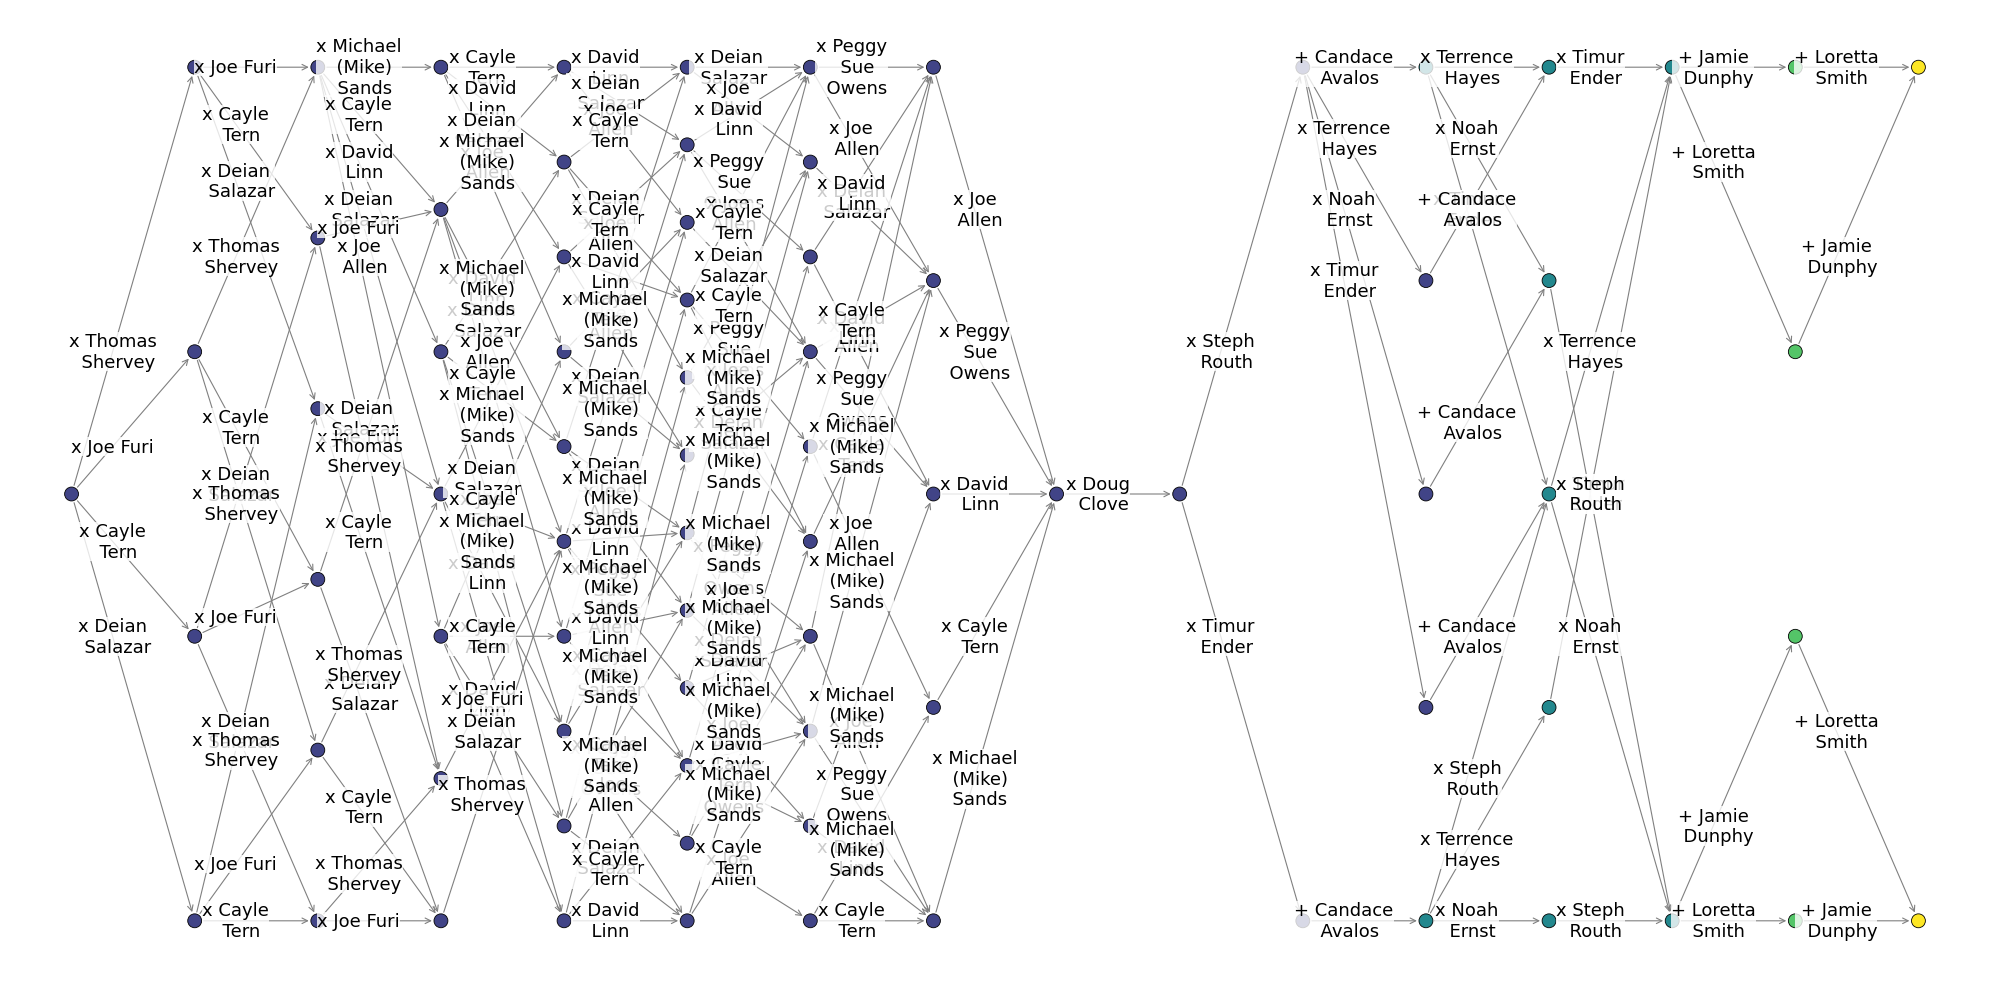

In [4]:
from src.plotting import plot_wigm_graph

plot_wigm_graph(
    constructor,
    figsize=(20, 10),
    node_size=100,
    font_size=14,
    #label_edges=None,
    #label_vertices=True,
    #lam_restriction=670,
    plot_horizontal=True,
    title="",
    #title="Portland D2 (15 candidates, 3 seats, N_votes =42678, Margin=2000)"
)

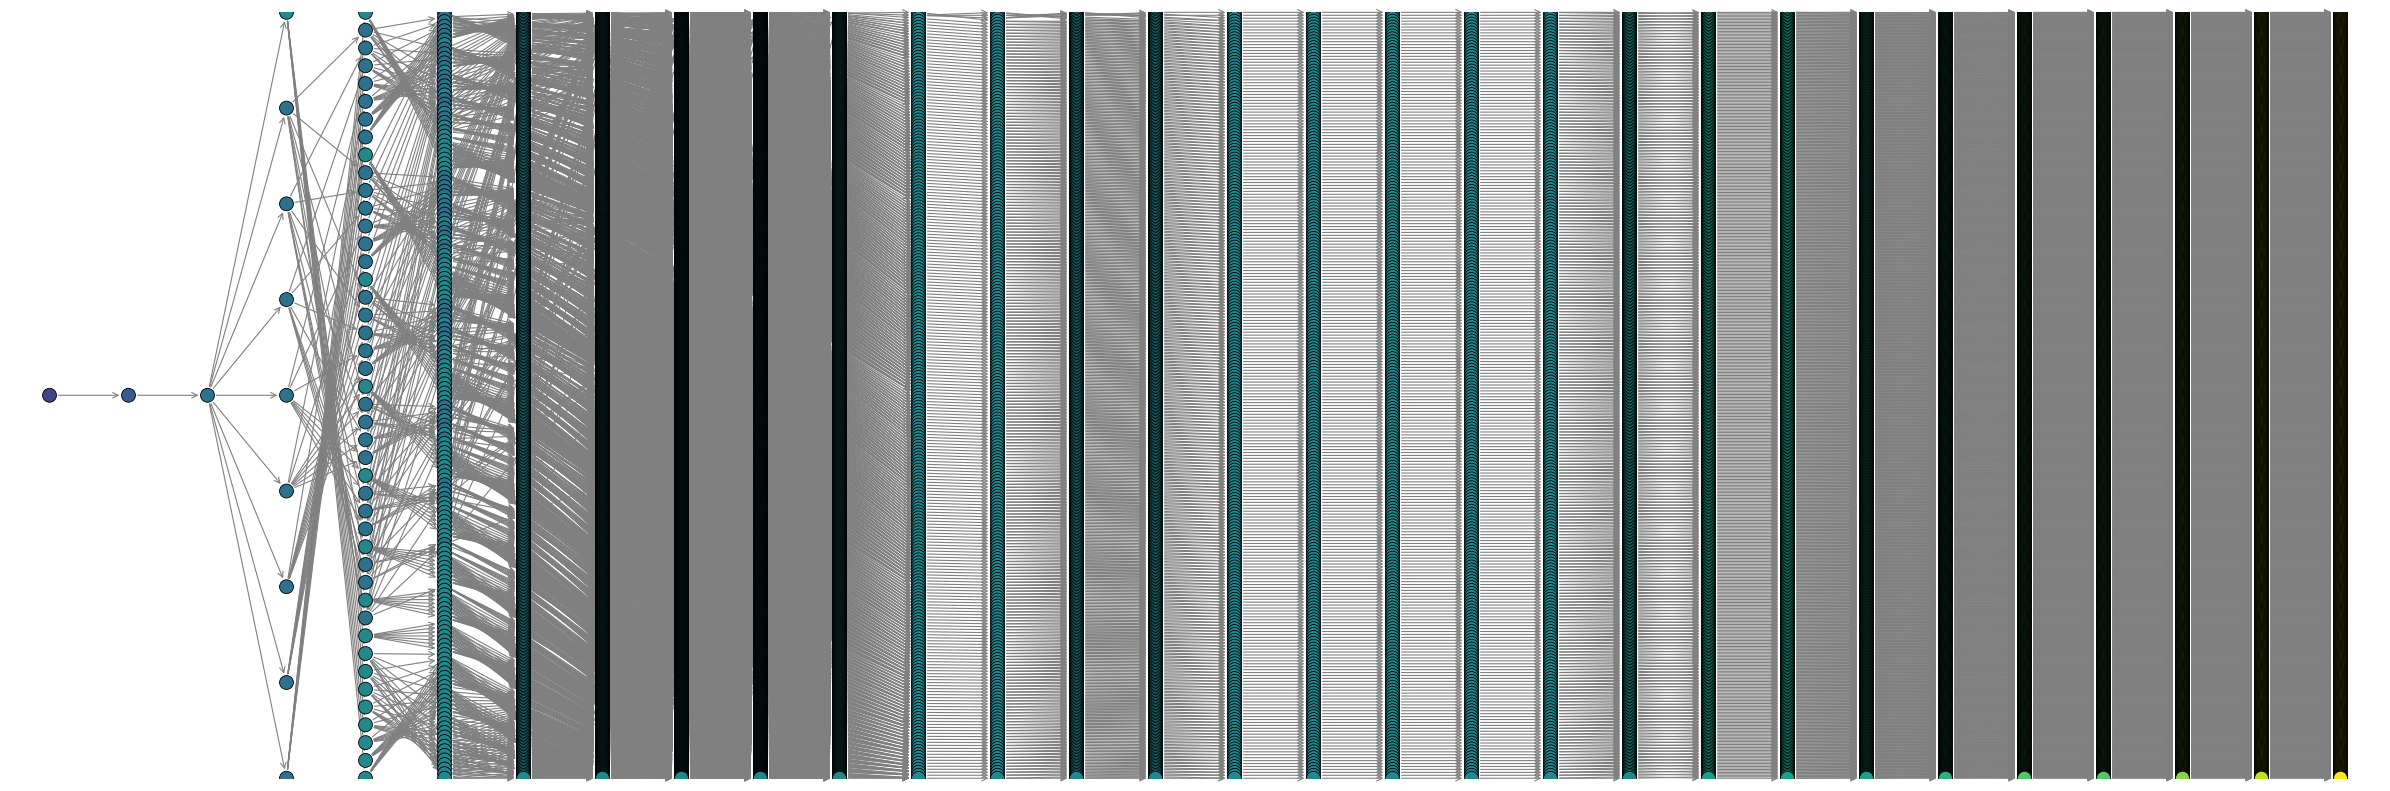

In [5]:
from src.plotting import plot_wigm_graph

plot_wigm_graph(
    constructor,
    figsize=(24, 8),
    node_size=100,
    font_size=14,
    label_edges=None,
    #label_vertices=True,
    #lam_restriction=670,
    plot_horizontal=True,
    title="",
    #title="Portland D2 (15 candidates, 3 seats, N_votes =42678, Margin=2000)"
)